<a href="https://colab.research.google.com/github/2303a51019/Data-Analaysis/blob/main/LAB_DEMO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms

# Check if CUDA is available and set the device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [ ]:
# Define a transform to normalize the data and convert to tensors
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# Load the MNIST training dataset
train_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

# Load the MNIST test dataset
test_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

# Create data loaders
batch_size = 64
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f'Number of training samples: {len(train_dataset)}')
print(f'Number of test samples: {len(test_dataset)}')
print(f'Number of training batches: {len(train_loader)}')
print(f'Number of test batches: {len(test_loader)}')

# Example of getting one batch of data and moving it to the device
for images, labels in train_loader:
    images = images.to(device)
    labels = labels.to(device)
    print(f'Shape of a batch of images: {images.shape}')
    print(f'Shape of a batch of labels: {labels.shape}')
    print(f'Images are on device: {images.device}')
    print(f'Labels are on device: {labels.device}')
    break

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 494kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.60MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.0MB/s]


Number of training samples: 60000
Number of test samples: 10000
Number of training batches: 938
Number of test batches: 157
Shape of a batch of images: torch.Size([64, 1, 28, 28])
Shape of a batch of labels: torch.Size([64])
Images are on device: cuda:0
Labels are on device: cuda:0


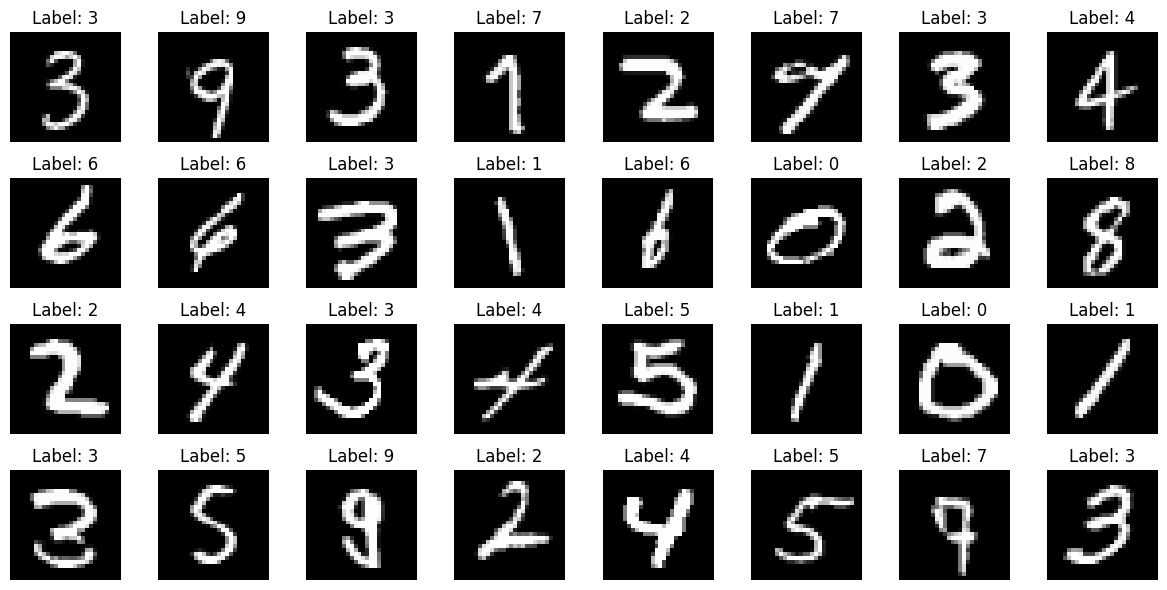

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Get one batch of training data
for images, labels in train_loader:
    break

# Move images and labels to CPU for visualization if they are on GPU
images = images.cpu()
labels = labels.cpu()

# Create a figure and a set of subplots
fig, axes = plt.subplots(nrows=4, ncols=8, figsize=(12, 6))

# Flatten the axes for easy iteration
axes = axes.flatten()

# Iterate over a subset of images and labels to display them
for i in range(32):
    # MNIST images are 1 channel, so squeeze it for display
    img = images[i].squeeze()
    label = labels[i].item()

    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f'Label: {label}')
    axes[i].axis('off') # Hide axes ticks and labels

plt.tight_layout() # Adjust layout to prevent overlapping titles
plt.show()

The code above visualizes the first 32 images from a batch of the training data. Each image is displayed with its corresponding digit label. The images are in grayscale, which is typical for the MNIST dataset.

In [ ]:
import torchvision.transforms as transforms

# The transformation pipeline applied to the MNIST dataset
# It converts images to PyTorch tensors and normalizes their pixel values.
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

print("Data preprocessing transform defined:")
print(transform)

Data preprocessing transform defined:
Compose(
    ToTensor()
    Normalize(mean=(0.1307,), std=(0.3081,))
)


This code block explicitly shows the `transform` object that is applied to each image in the MNIST dataset. It performs two main operations:

1.  **`transforms.ToTensor()`**: This converts the image from a PIL Image or NumPy array to a PyTorch `Tensor`. It also scales the pixel intensity values from the range [0, 255] to [0.0, 1.0].
2.  **`transforms.Normalize((0.1307,), (0.3081,))`**: This normalizes the tensor by subtracting the mean (0.1307) and dividing by the standard deviation (0.3081). These values are specific to the MNIST dataset (calculated over all training images) and help in standardizing the input data for neural networks, often leading to faster and more stable training.